### 🚀 Open this Tutorial in Google Colab  
<a target="_blank" href="https://colab.research.google.com/github/amirhszd/MachineLearning4RemoteSensing/blob/main/hw5/hw5_p1.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

###Mount Google Drive and Load Data

In this step, you’ll mount your Google Drive so that you can access .npy files directly from it. Then, load your training, validation, and test sets using NumPy. Be sure to update the paths to point to your own data files.

Make sure to set to runtime session to use GPU otherwise your training is going to be slow.

In [14]:
# import files and mount google drive
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# Step 1: Load your .npy files from your Google Drive
# TODO: Replace the paths below with the correct paths to your own files

X_train = np.load('/content/drive/MyDrive/chlorophyll/landis_chlorophyl_regression_train.npy')
y_train = np.load('/content/drive/MyDrive/chlorophyll/landis_chlorophyl_regression_traingt.npy')

X_val = np.load('/content/drive/MyDrive/chlorophyll/landis_chlorophyl_regression_val.npy')
y_val = np.load('/content/drive/MyDrive/chlorophyll/landis_chlorophyl_regression_valgt.npy')

X_test = np.load('/content/drive/MyDrive/chlorophyll/landis_chlorophyl_regression_test.npy')
y_test = np.load('/content/drive/MyDrive/chlorophyll/landis_chlorophyl_regression_testgt.npy')

print("Training set shape:", X_train.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training set shape: (6000, 425)


### Standardize the Data & Create Dataset

Here, you will standardize your dataset using StandardScaler. This ensures that each feature has zero mean and unit variance. Remember to fit the scaler only on the training data, and then transform all splits using that same scaler.

You’ll define a custom PyTorch Dataset to wrap your data and make it compatible with DataLoader. After that, instantiate the datasets and set up data loaders with appropriate batch size and parallel loading settings (num_workers, prefetch_factor).

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Step 1: Standard scaling based on training data only
# Fit scaler on training data and transform all splits
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete!")
print(f"Training data - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")

# Step 2: Create custom dataset class
class ChlorophyllDataset(Dataset):
    def __init__(self, X, y):
        # Convert numpy arrays to torch tensors with float32 dtype
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

        # Reshape X to add channel dimension for Conv1D: (N, 425) -> (N, 1, 425)
        # Conv1D expects (batch_size, channels, length)
        if len(self.X.shape) == 2:
            self.X = self.X.unsqueeze(1)  # Add channel dimension

        # Reshape y to be (N, 1) for regression
        if len(self.y.shape) == 1:
            self.y = self.y.unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Step 3: Instantiate your datasets
train_dataset = ChlorophyllDataset(X_train_scaled, y_train)
val_dataset = ChlorophyllDataset(X_val_scaled, y_val)
test_dataset = ChlorophyllDataset(X_test_scaled, y_test)

# Step 4: Create DataLoaders

batch_size = 64
num_workers = 2
prefetch_factor = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    prefetch_factor=prefetch_factor if num_workers > 0 else None,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    prefetch_factor=prefetch_factor if num_workers > 0 else None,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    prefetch_factor=prefetch_factor if num_workers > 0 else None,
    pin_memory=True
)

print("train dataset size is:", len(train_dataset))
print("val dataset size is:", len(val_dataset))
print("test dataset size is:", len(test_dataset))

# Verify data shape
sample_X, sample_y = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"Input (X): {sample_X.shape}")  # Should be (batch_size, 1, 425)
print(f"Target (y): {sample_y.shape}")  # Should be (batch_size, 1)

Scaling complete!
Training data - Mean: -0.000000, Std: 1.000000
train dataset size is: 6000
val dataset size is: 2000
test dataset size is: 2000

Batch shapes:
Input (X): torch.Size([64, 1, 425])
Target (y): torch.Size([64, 1])


### Define Your 1D Convolutional Model
In this step, you’ll define a custom SpectralCNN model using PyTorch’s nn Module. This model consists of a sequence of 1D convolutional layers with increasing filter sizes and stride to reduce the spectral dimension. The final Linear layer maps the learned features to a single output value for regression.

💡 Note: Since your input has shape [batch_size, 425], you’ll need to change the shape accordingly.

In [16]:
import torch.nn as nn

class SpectralCNN(nn.Module):
    def __init__(self):
        super(SpectralCNN, self).__init__()
        # 8 layer 1D CNN with kernel size 3 and stride of 2
        # stride 2 lowers the dimensionality spectral dimensionality
        # relu is the activation function introducing nonlinearity
        # the bigger the kernel size the more number of parameters to learn
        self.net = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, stride=2), nn.ReLU(),  # [B, 8, 212]
            nn.Conv1d(8, 16, kernel_size=3, stride=2), nn.ReLU(), # [B, 16, 105]
            nn.Conv1d(16, 32, kernel_size=3, stride=2), nn.ReLU(),# [B, 32, 52]
            nn.Conv1d(32, 64, kernel_size=3, stride=2), nn.ReLU(),# [B, 64, 25]
            nn.Conv1d(64, 128, kernel_size=3, stride=2), nn.ReLU(),# [B, 128, 12]
            nn.Conv1d(128, 128, kernel_size=3, stride=2), nn.ReLU(),# [B, 128, 5]
            nn.Conv1d(128, 256, kernel_size=3, stride=2), nn.ReLU(),# [B, 256, 2]
            nn.Conv1d(256, 256, kernel_size=2, stride=1), nn.ReLU(),# [B, 256, 1]
            nn.Flatten(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        # x comes in as (N, 425) from our dataset
        # We need to add channel dimension: (N, 425) -> (N, 1, 425)
        # For 1D Conv: N x C_in x Length
        # Where: N = batch size, C_in = 1 channel, Length = 425 spectral bands

        if len(x.shape) == 2:  # If shape is (N, 425)
            x = x.unsqueeze(1)  # Add channel dim: (N, 1, 425)

        return self.net(x)

### Define the Model, Optimizer, and Training Configuration

In this section, you will define the loss function for your regression task, instantiate your model, and set up the optimizer of your choice. Make sure to use weight decay to prevent overfitting.

Your training will benefit from learning rate scheduler such as to gradually reduce the learning rate during training. Finally, you’ll move your model to the GPU if available.

💡 Tip: Your learning rate and weight decay are hyperparameters!

In [17]:
import torch.optim as optim

# TODO: Define regression LOSS
# MSE (Mean Squared Error) is standard for regression tasks
criterion = nn.MSELoss()

# instantiating the model
model = SpectralCNN()

# TODO: define optimizer, suggestion is Adam with weight decay.
learning_rate = 1e-3      # Common starting point: 0.001
weight_decay = 1e-4       # L2 regularization to prevent overfitting

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# TODO: you can define a learning rate scheduler at the time of training
# ReduceLROnPlateau: reduces LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',           # Minimize validation loss
    factor=0.5,           # Reduce LR by half
    patience=5,           # Wait 5 epochs before reducing
    min_lr=1e-6           # Don't go below this LR
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Using:", device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using: cuda
Model parameters: 312,337


### Training Loop and Early Stopping

In this section, you will implement the full training loop for your model. For each epoch, you’ll:
	•	Loop through your training data
	•	Send batches to the correct device
	•	Perform forward and backward passes
	•	Update the model using your optimizer

After training on each epoch, you’ll evaluate your model on the validation set without computing gradients. You’ll track the best-performing model based on validation loss and save it using torch.save(). Finally, you’ll step the learning rate scheduler to gradually reduce the learning rate over time.

Make sure to plot loss for training and validation sets, this will help you see into overfitting and underfitting.

🛑 Don’t forget: only update weights during training, and use torch.no_grad() during validation to save memory and speed up evaluation.

✓ New best model saved!
Epoch 1/50 | Train Loss: 754.7710 | Val Loss: 525.9507 | LR: 0.001000
✓ New best model saved!
Epoch 2/50 | Train Loss: 332.2058 | Val Loss: 74.6678 | LR: 0.001000
✓ New best model saved!
Epoch 3/50 | Train Loss: 37.5934 | Val Loss: 19.1763 | LR: 0.001000
✓ New best model saved!
Epoch 4/50 | Train Loss: 17.7266 | Val Loss: 14.4284 | LR: 0.001000
✓ New best model saved!
Epoch 5/50 | Train Loss: 15.0863 | Val Loss: 12.5643 | LR: 0.001000
✓ New best model saved!
Epoch 6/50 | Train Loss: 15.7228 | Val Loss: 11.8565 | LR: 0.001000
Epoch 7/50 | Train Loss: 15.1185 | Val Loss: 15.1796 | LR: 0.001000
Epoch 8/50 | Train Loss: 15.1748 | Val Loss: 12.0952 | LR: 0.001000
Epoch 9/50 | Train Loss: 16.7183 | Val Loss: 17.2793 | LR: 0.001000
✓ New best model saved!
Epoch 10/50 | Train Loss: 14.0478 | Val Loss: 11.5205 | LR: 0.001000
Epoch 11/50 | Train Loss: 14.7369 | Val Loss: 13.7364 | LR: 0.001000
Epoch 12/50 | Train Loss: 13.7500 | Val Loss: 12.7744 | LR: 0.001000
Epoch 13/5

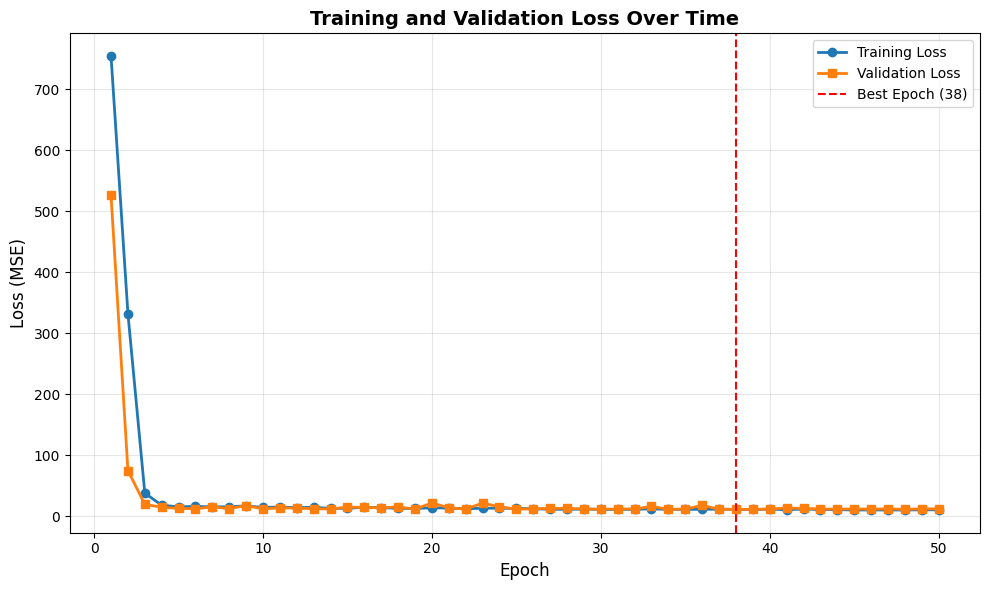


 Model Performance Analysis:
Final Training Loss: 10.2186
Final Validation Loss: 11.7491
Train-Val Gap: 1.5305


In [18]:
import matplotlib.pyplot as plt

# Initialize variables for early stopping
best_val_loss = float("inf")
best_epoch = -1

# keeping track of validation loss and training loss for plotting
val_loss_history = []
train_loss_history = []

# Training loop
epochs = 50
for epoch in range(epochs):
    model.train()
    train_losses = []

    # TODO: keep track of any other regression metric you want per epoch

    for X_batch, y_batch in train_loader:
        # TODO: send input features and reference target to device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # zeroing out previous step gradients
        optimizer.zero_grad()

        # forward pass: send input features through model
        outputs = model(X_batch)

        # TODO: calculate the loss
        loss = criterion(outputs, y_batch)

        # TODO: calculate the gradients by calling backward on the loss
        loss.backward()

        # TODO: take a step by calling step on the optimizer
        optimizer.step()

        # TODO: keep score of your training loss and any other metric you see fit for
        # your regression task
        train_losses.append(loss.item())

    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            # TODO: Same as training but we are not updating weights
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            val_loss = criterion(outputs, y_batch)
            val_losses.append(val_loss.item())

    # TODO: implementing early stopping here.
    # keep track of the validation loss and save the model parameters when the loss is the lowest for the validation set
    train_loss_mean = np.mean(train_losses)
    val_loss_mean = np.mean(val_losses)

    train_loss_history.append(train_loss_mean)
    val_loss_history.append(val_loss_mean)

    if val_loss_mean < best_val_loss:
        best_val_loss = val_loss_mean
        best_epoch = epoch
        torch.save(model.state_dict(), "best_model.pt")
        print(f"✓ New best model saved!")

    # TODO: take a step in the scheduler to update the learning rate
    scheduler.step(val_loss_mean)

    # Print summary
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss_mean:.4f} | Val Loss: {val_loss_mean:.4f} | LR: {current_lr:.6f}")

print(f"\n{'='*60}")
print(f"Best model saved from epoch {best_epoch+1} with Val Loss: {best_val_loss:.4f}")
print(f"{'='*60}")

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), train_loss_history, label='Training Loss', marker='o', linewidth=2)
plt.plot(range(1, epochs+1), val_loss_history, label='Validation Loss', marker='s', linewidth=2)
plt.axvline(x=best_epoch+1, color='r', linestyle='--', label=f'Best Epoch ({best_epoch+1})')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss Over Time', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze overfitting/underfitting
final_train_loss = train_loss_history[-1]
final_val_loss = val_loss_history[-1]
gap = final_val_loss - final_train_loss

print("\n Model Performance Analysis:")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Train-Val Gap: {gap:.4f}")



### Get predictions and plot your results
Get predictions on your test set and plot your regression results for your training and test set.

Getting predictions...

Training Set Metrics:
R² Score:       0.9802
MAE:            2.1886
RMSE:           3.1624
MSE:            10.0011
MAPE:           5.95%

Validation Set Metrics:
R² Score:       0.9796
MAE:            2.3179
RMSE:           3.3055
MSE:            10.9264
MAPE:           6.24%

Test Set Metrics:
R² Score:       0.9770
MAE:            2.3804
RMSE:           3.4645
MSE:            12.0029
MAPE:           6.30%


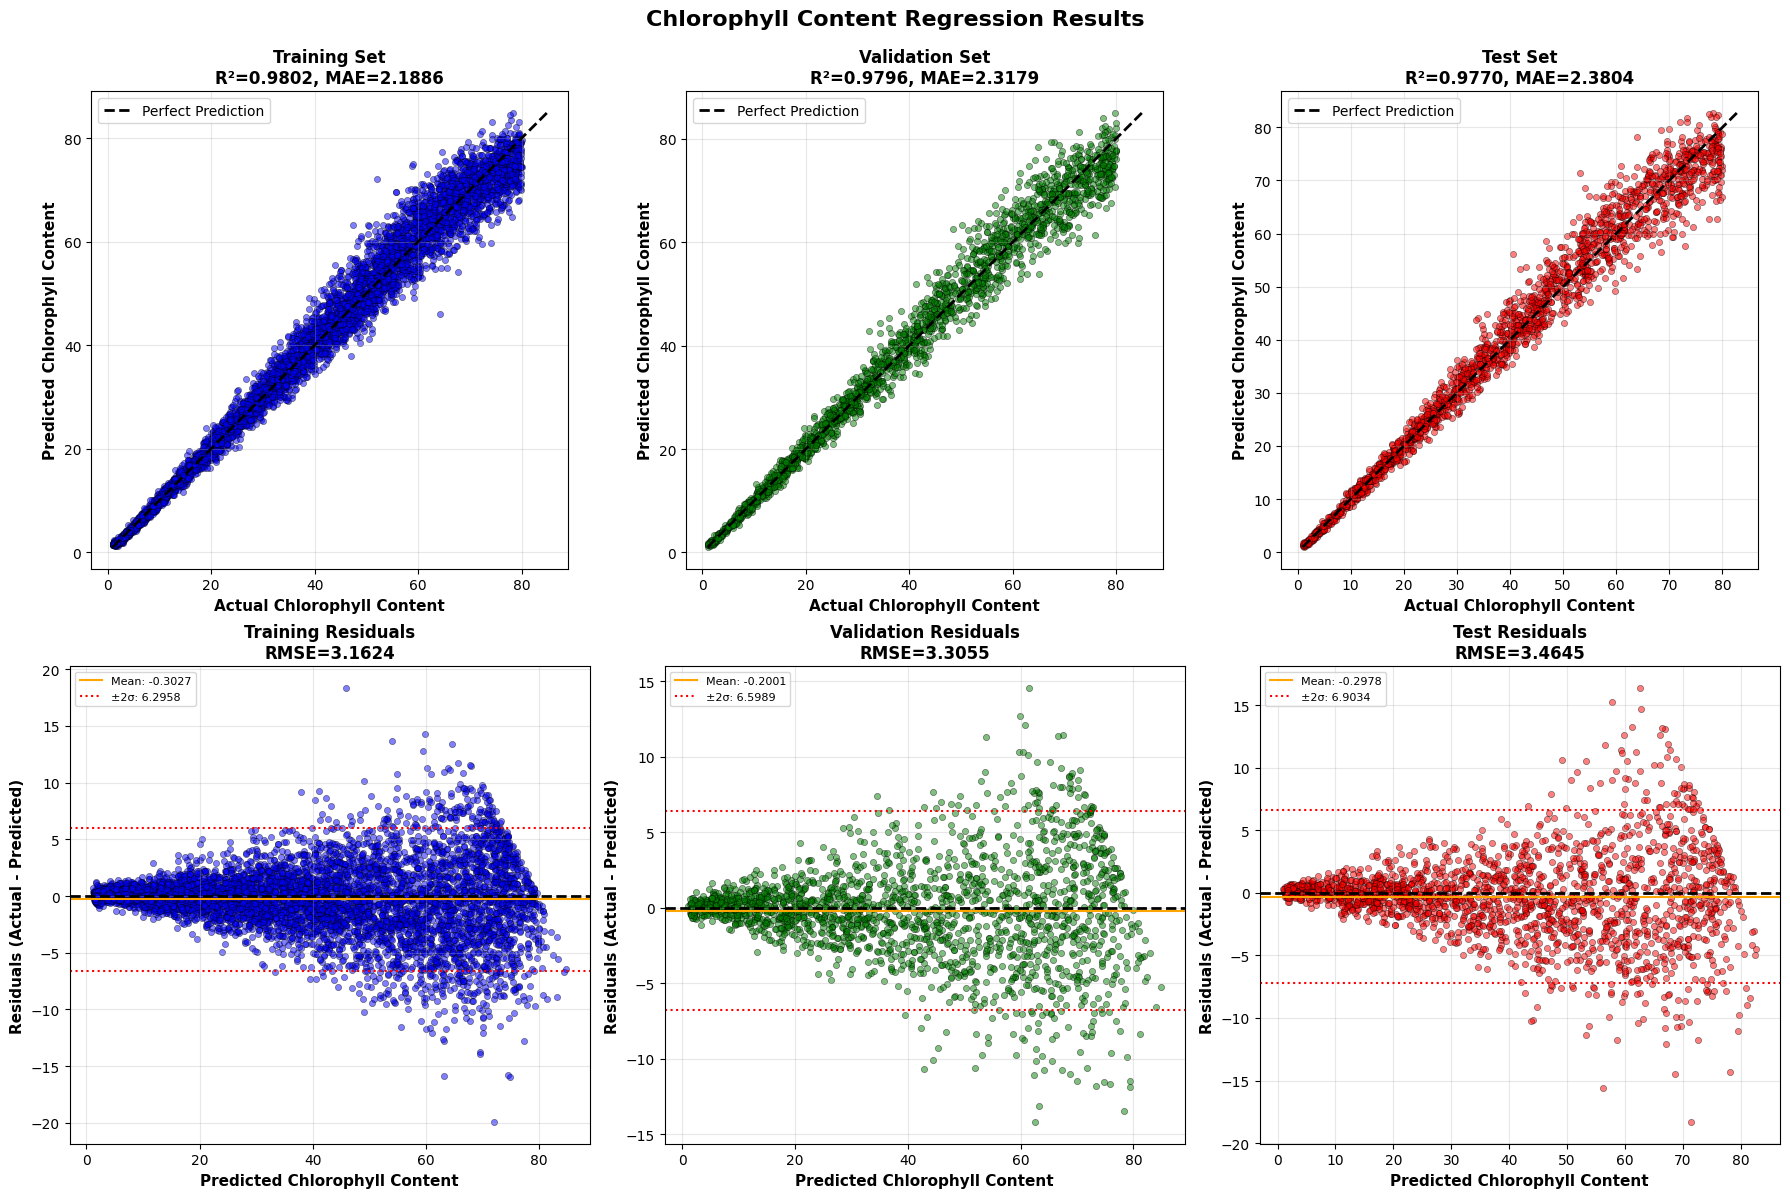

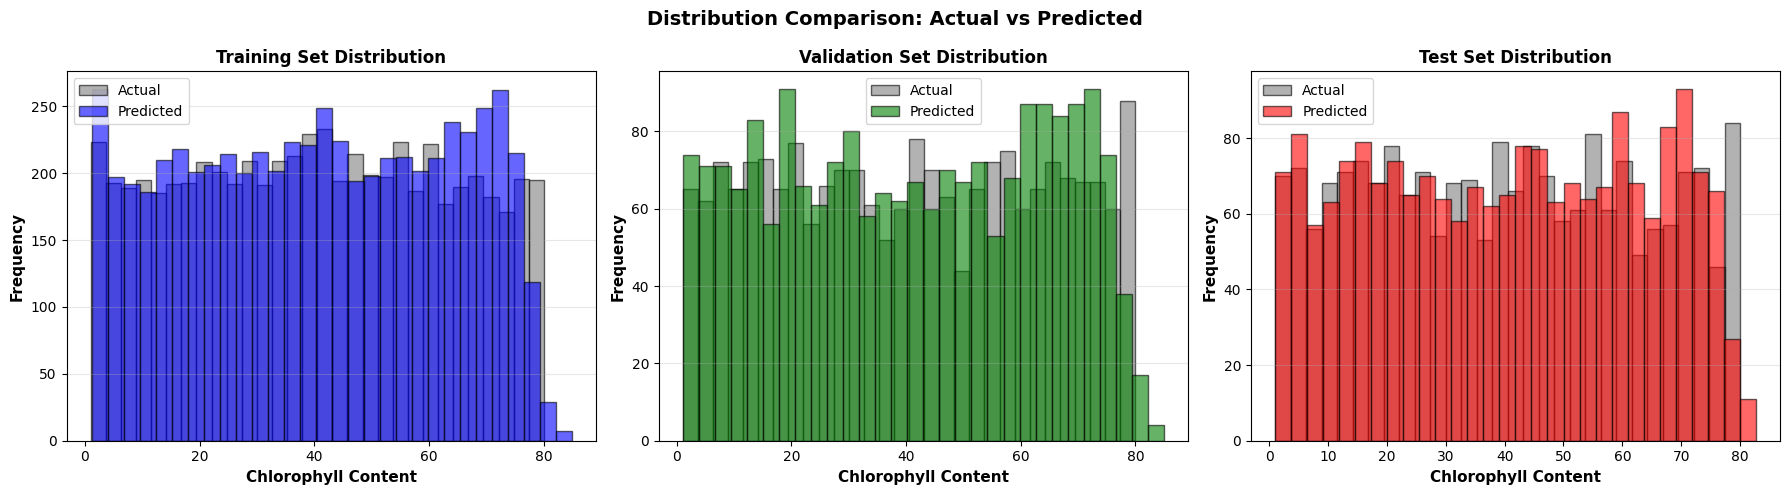


ANALYSIS SUMMARY

 Model Generalization:
Train-Val R² Gap:  0.0007
Val-Test R² Gap:   0.0026
 Model generalizes well across all datasets

 Performance Level:
 Excellent performance (R² = 0.9770)

 Residual Analysis:
  Model tends to overpredict (mean residual: -0.2978)



In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# Load the best model
model.load_state_dict(torch.load("best_model.pt", weights_only=True))
model.eval()  # Set model to evaluation mode
model.to(device)  # Ensure model is on correct device

# Function to get predictions for any dataset
def get_predictions(model, data_loader, device):
    """Get predictions and ground truth from a data loader"""
    all_preds = []
    all_targets = []

    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)

            all_preds.append(outputs.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    # Concatenate all batches
    predictions = np.concatenate(all_preds).flatten()
    targets = np.concatenate(all_targets).flatten()

    return predictions, targets

# Get predictions for all datasets
print("Getting predictions...")
train_preds, train_targets = get_predictions(model, train_loader, device)
val_preds, val_targets = get_predictions(model, val_loader, device)
test_preds, test_targets = get_predictions(model, test_loader, device)

# Calculate metrics for all sets
def calculate_metrics(y_true, y_pred, dataset_name):
    """Calculate and print regression metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Calculate relative errors
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"\n{'='*50}")
    print(f"{dataset_name} Set Metrics:")
    print(f"{'='*50}")
    print(f"R² Score:       {r2:.4f}")
    print(f"MAE:            {mae:.4f}")
    print(f"RMSE:           {rmse:.4f}")
    print(f"MSE:            {mse:.4f}")
    print(f"MAPE:           {mape:.2f}%")

    return {"mae": mae, "mse": mse, "rmse": rmse, "r2": r2, "mape": mape}

# Calculate metrics
train_metrics = calculate_metrics(train_targets, train_preds, "Training")
val_metrics = calculate_metrics(val_targets, val_preds, "Validation")
test_metrics = calculate_metrics(test_targets, test_preds, "Test")


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Chlorophyll Content Regression Results', fontsize=16, fontweight='bold', y=0.995)

datasets = [
    (train_preds, train_targets, train_metrics, 'Training', 'blue'),
    (val_preds, val_targets, val_metrics, 'Validation', 'green'),
    (test_preds, test_targets, test_metrics, 'Test', 'red')
]

for idx, (preds, targets, metrics, name, color) in enumerate(datasets):
    # Row 1: Regression plots (Predicted vs Actual)
    ax1 = axes[0, idx]
    ax1.scatter(targets, preds, alpha=0.5, s=20, color=color, edgecolors='k', linewidth=0.5)

    # Perfect prediction line
    min_val = min(targets.min(), preds.min())
    max_val = max(targets.max(), preds.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

    ax1.set_xlabel('Actual Chlorophyll Content', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Predicted Chlorophyll Content', fontsize=11, fontweight='bold')
    ax1.set_title(f'{name} Set\nR²={metrics["r2"]:.4f}, MAE={metrics["mae"]:.4f}',
                  fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal', adjustable='box')

    # Row 2: Residual plots
    ax2 = axes[1, idx]
    residuals = targets - preds
    ax2.scatter(preds, residuals, alpha=0.5, s=20, color=color, edgecolors='k', linewidth=0.5)
    ax2.axhline(y=0, color='k', linestyle='--', lw=2)

    # Add mean and std lines
    mean_residual = residuals.mean()
    std_residual = residuals.std()
    ax2.axhline(y=mean_residual, color='orange', linestyle='-', lw=1.5,
                label=f'Mean: {mean_residual:.4f}')
    ax2.axhline(y=mean_residual + 2*std_residual, color='red', linestyle=':', lw=1.5,
                label=f'±2σ: {2*std_residual:.4f}')
    ax2.axhline(y=mean_residual - 2*std_residual, color='red', linestyle=':', lw=1.5)

    ax2.set_xlabel('Predicted Chlorophyll Content', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=11, fontweight='bold')
    ax2.set_title(f'{name} Residuals\nRMSE={metrics["rmse"]:.4f}',
                  fontsize=12, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional Analysis: Distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution Comparison: Actual vs Predicted', fontsize=14, fontweight='bold')

for idx, (preds, targets, metrics, name, color) in enumerate(datasets):
    ax = axes[idx]
    ax.hist(targets, bins=30, alpha=0.6, label='Actual', color='gray', edgecolor='black')
    ax.hist(preds, bins=30, alpha=0.6, label='Predicted', color=color, edgecolor='black')
    ax.set_xlabel('Chlorophyll Content', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'{name} Set Distribution', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print analysis summary
print(f"\n{'='*70}")
print("ANALYSIS SUMMARY")
print(f"{'='*70}")

print("\n Model Generalization:")
train_val_gap = abs(train_metrics['r2'] - val_metrics['r2'])
val_test_gap = abs(val_metrics['r2'] - test_metrics['r2'])

print(f"Train-Val R² Gap:  {train_val_gap:.4f}")
print(f"Val-Test R² Gap:   {val_test_gap:.4f}")

if train_val_gap > 0.1:
    print("  Significant gap between training and validation - possible overfitting")
elif val_test_gap > 0.05:
    print("  Validation and test performance differ - check data distribution")
else:
    print(" Model generalizes well across all datasets")

print("\n Performance Level:")
if test_metrics['r2'] > 0.9:
    print(f" Excellent performance (R² = {test_metrics['r2']:.4f})")
elif test_metrics['r2'] > 0.7:
    print(f" Good performance (R² = {test_metrics['r2']:.4f})")
elif test_metrics['r2'] > 0.5:
    print(f"  Moderate performance (R² = {test_metrics['r2']:.4f})")
else:
    print(f"  Poor performance (R² = {test_metrics['r2']:.4f}) - consider model improvements")

print("\n Residual Analysis:")
test_residuals = test_targets - test_preds
residual_bias = np.mean(test_residuals)
if abs(residual_bias) < 0.01:
    print(f" Unbiased predictions (mean residual: {residual_bias:.6f})")
elif residual_bias > 0:
    print(f"  Model tends to underpredict (mean residual: {residual_bias:.4f})")
else:
    print(f"  Model tends to overpredict (mean residual: {residual_bias:.4f})")

print(f"\n{'='*70}")

I am attaching the test results from Xgboost here for your reference! Your tuned model should outpefrom this performance:

MAE=3.22, R2=0.96

![xgboost](xgboost.png)

### Hyperparamter Tuning
This part is all you. You have a base model that is performing somewhat accurately for you. Grab a package and perform hyperparameter tuning on your hyperparameters. Read Below!!!

In [20]:
# TODO: now that we have a base model that things are working, we perform hyperparameter tuning on validation data

# change the learning rate value
# number of layers
# filter size (the bigger the filter size the more computationally expensive)
# instead of ReLU use leaky Relu or Tanh
# learning weight decay
# using max/average pooling instead of stride 2
# icorporating padding
# you can log the lowest loss (highest accuracy) on your validation set and report that



Experiment 1: BASELINE MODEL
Epoch 1/50 | Train Loss: 767.1869 | Val Loss: 535.7125 | Val R²: 0.0025 | Val MAE: 20.0697
Epoch 11/50 | Train Loss: 15.0537 | Val Loss: 12.2993 | Val R²: 0.9770 | Val MAE: 2.5077
Epoch 21/50 | Train Loss: 11.2763 | Val Loss: 12.1194 | Val R²: 0.9774 | Val MAE: 2.4345
Epoch 31/50 | Train Loss: 11.2755 | Val Loss: 12.5838 | Val R²: 0.9766 | Val MAE: 2.5301
Epoch 41/50 | Train Loss: 10.6890 | Val Loss: 11.3279 | Val R²: 0.9789 | Val MAE: 2.3704
Epoch 50/50 | Train Loss: 9.8479 | Val Loss: 11.5363 | Val R²: 0.9786 | Val MAE: 2.3821

Experiment 2: HIGHER LEARNING RATE (5e-3)
Epoch 1/50 | Train Loss: 682.3918 | Val Loss: 536.2128 | Val R²: 0.0030 | Val MAE: 19.9852
Epoch 11/50 | Train Loss: 14.6229 | Val Loss: 13.6638 | Val R²: 0.9744 | Val MAE: 2.6059
Epoch 21/50 | Train Loss: 12.6651 | Val Loss: 18.7926 | Val R²: 0.9647 | Val MAE: 3.2176
Epoch 31/50 | Train Loss: 10.9675 | Val Loss: 12.6261 | Val R²: 0.9763 | Val MAE: 2.4305
Epoch 41/50 | Train Loss: 9.3142 |

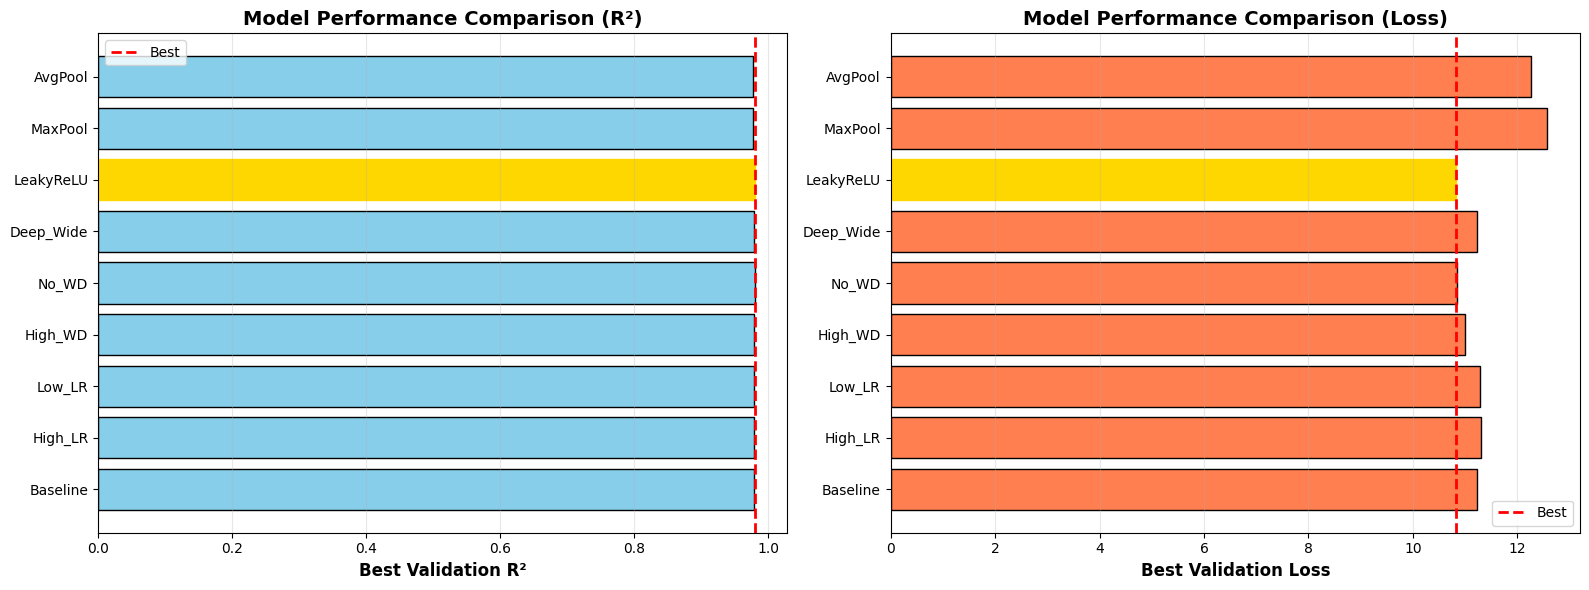

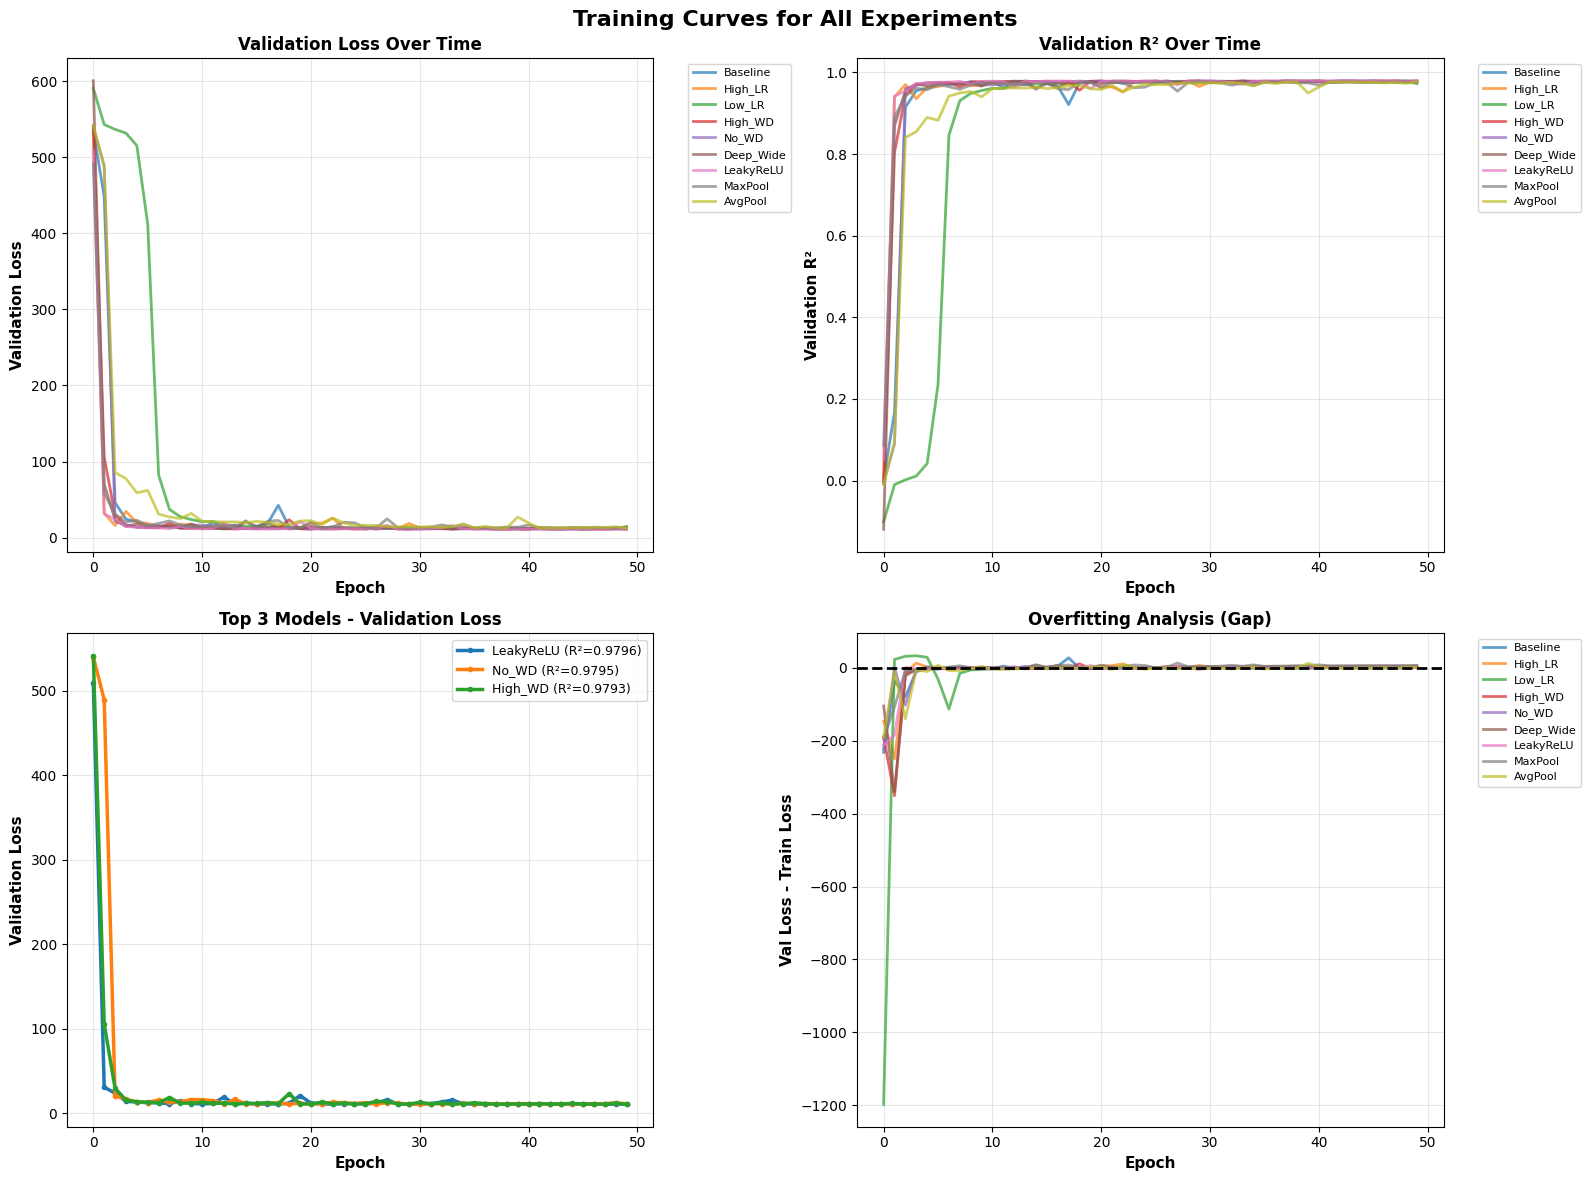

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error


# DEFINE VARIOUS MODEL ARCHITECTURES


class SpectralCNN_Baseline(nn.Module):

    def __init__(self):
        super(SpectralCNN_Baseline, self).__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=2, stride=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        return self.net(x)


class SpectralCNN_DeepWide(nn.Module):

    def __init__(self):
        super(SpectralCNN_DeepWide, self).__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(256, 512, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv1d(512, 512, kernel_size=2, stride=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        return self.net(x)


class SpectralCNN_LeakyReLU(nn.Module):

    def __init__(self):
        super(SpectralCNN_LeakyReLU, self).__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, stride=2), nn.LeakyReLU(0.2),
            nn.Conv1d(8, 16, kernel_size=3, stride=2), nn.LeakyReLU(0.2),
            nn.Conv1d(16, 32, kernel_size=3, stride=2), nn.LeakyReLU(0.2),
            nn.Conv1d(32, 64, kernel_size=3, stride=2), nn.LeakyReLU(0.2),
            nn.Conv1d(64, 128, kernel_size=3, stride=2), nn.LeakyReLU(0.2),
            nn.Conv1d(128, 128, kernel_size=3, stride=2), nn.LeakyReLU(0.2),
            nn.Conv1d(128, 256, kernel_size=3, stride=2), nn.LeakyReLU(0.2),
            nn.Conv1d(256, 256, kernel_size=2, stride=1), nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        return self.net(x)


class SpectralCNN_LargeKernel(nn.Module):

    def __init__(self):
        super(SpectralCNN_LargeKernel, self).__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=7, stride=2, padding=3), nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=2, stride=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        return self.net(x)


class SpectralCNN_MaxPooling(nn.Module):

    def __init__(self):
        super(SpectralCNN_MaxPooling, self).__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(8, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(256, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(768, 1)  # Adjusted based on pooling
        )

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        return self.net(x)

#Model using AvgPooling instead of stride 2
class SpectralCNN_AvgPooling(nn.Module):
    def __init__(self):
        super(SpectralCNN_AvgPooling, self).__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.AvgPool1d(2),
            nn.Conv1d(8, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.AvgPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AvgPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.AvgPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AvgPool1d(2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AvgPool1d(2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.AvgPool1d(2),
            nn.Conv1d(256, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(768, 1)
        )

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        return self.net(x)



# TRAINING FUNCTION


def train_model(model, train_loader, val_loader, config, device, verbose=False):

    criterion = nn.MSELoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=config.get('patience', 5),
        min_lr=1e-6
    )

    best_val_loss = float('inf')
    best_val_r2 = -float('inf')
    best_epoch = -1

    train_losses = []
    val_losses = []
    val_r2s = []

    epochs = config.get('epochs', 50)

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_train_losses.append(loss.item())

        # Validation
        model.eval()
        epoch_val_losses = []
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                val_loss = criterion(outputs, y_batch)
                epoch_val_losses.append(val_loss.item())

                all_preds.append(outputs.cpu().numpy())
                all_targets.append(y_batch.cpu().numpy())

        # Calculate metrics
        train_loss_mean = np.mean(epoch_train_losses)
        val_loss_mean = np.mean(epoch_val_losses)

        all_preds = np.concatenate(all_preds).flatten()
        all_targets = np.concatenate(all_targets).flatten()
        val_r2 = r2_score(all_targets, all_preds)
        val_mae = mean_absolute_error(all_targets, all_preds)

        train_losses.append(train_loss_mean)
        val_losses.append(val_loss_mean)
        val_r2s.append(val_r2)

        # Track best model
        if val_loss_mean < best_val_loss:
            best_val_loss = val_loss_mean
            best_val_r2 = val_r2
            best_epoch = epoch

        # Learning rate scheduling
        scheduler.step(val_loss_mean)

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss_mean:.4f} | "
                  f"Val Loss: {val_loss_mean:.4f} | Val R²: {val_r2:.4f} | Val MAE: {val_mae:.4f}")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_r2s': val_r2s,
        'best_val_loss': best_val_loss,
        'best_val_r2': best_val_r2,
        'best_epoch': best_epoch
    }



# HYPERPARAMETER TUNING EXPERIMENTS


def run_hyperparameter_experiments(train_loader, val_loader, device):
    """
    Run comprehensive hyperparameter tuning experiments
    """
    results = []

    # Experiment 1: Baseline
    print("\n" + "="*70)
    print("Experiment 1: BASELINE MODEL")
    print("="*70)
    config = {
        'name': 'Baseline',
        'lr': 1e-3,
        'weight_decay': 1e-4,
        'epochs': 50,
        'patience': 5
    }
    model = SpectralCNN_Baseline().to(device)
    history = train_model(model, train_loader, val_loader, config, device, verbose=True)
    results.append({**config, **history})

    # Experiment 2: Higher Learning Rate
    print("\n" + "="*70)
    print("Experiment 2: HIGHER LEARNING RATE (5e-3)")
    print("="*70)
    config = {
        'name': 'High_LR',
        'lr': 5e-3,
        'weight_decay': 1e-4,
        'epochs': 50,
        'patience': 5
    }
    model = SpectralCNN_Baseline().to(device)
    history = train_model(model, train_loader, val_loader, config, device, verbose=True)
    results.append({**config, **history})

    # Experiment 3: Lower Learning Rate
    print("\n" + "="*70)
    print("Experiment 3: LOWER LEARNING RATE (1e-4)")
    print("="*70)
    config = {
        'name': 'Low_LR',
        'lr': 1e-4,
        'weight_decay': 1e-4,
        'epochs': 50,
        'patience': 5
    }
    model = SpectralCNN_Baseline().to(device)
    history = train_model(model, train_loader, val_loader, config, device, verbose=True)
    results.append({**config, **history})

    # Experiment 4: Higher Weight Decay- more regularization
    print("\n" + "="*70)
    print("Experiment 4: HIGHER WEIGHT DECAY (1e-3)")
    print("="*70)
    config = {
        'name': 'High_WD',
        'lr': 1e-3,
        'weight_decay': 1e-3,
        'epochs': 50,
        'patience': 5
    }
    model = SpectralCNN_Baseline().to(device)
    history = train_model(model, train_loader, val_loader, config, device, verbose=True)
    results.append({**config, **history})

    # Experiment 5: No Weight Decay
    print("\n" + "="*70)
    print("Experiment 5: NO WEIGHT DECAY")
    print("="*70)
    config = {
        'name': 'No_WD',
        'lr': 1e-3,
        'weight_decay': 0,
        'epochs': 50,
        'patience': 5
    }
    model = SpectralCNN_Baseline().to(device)
    history = train_model(model, train_loader, val_loader, config, device, verbose=True)
    results.append({**config, **history})

    # Experiment 6: Deeper and Wider Model
    print("\n" + "="*70)
    print("Experiment 6: DEEPER & WIDER MODEL")
    print("="*70)
    config = {
        'name': 'Deep_Wide',
        'lr': 1e-3,
        'weight_decay': 1e-4,
        'epochs': 50,
        'patience': 5
    }
    model = SpectralCNN_DeepWide().to(device)
    history = train_model(model, train_loader, val_loader, config, device, verbose=True)
    results.append({**config, **history})

    # Experiment 7: LeakyReLU Activation
    print("\n" + "="*70)
    print("Experiment 7: LEAKY ReLU ACTIVATION")
    print("="*70)
    config = {
        'name': 'LeakyReLU',
        'lr': 1e-3,
        'weight_decay': 1e-4,
        'epochs': 50,
        'patience': 5
    }
    model = SpectralCNN_LeakyReLU().to(device)
    history = train_model(model, train_loader, val_loader, config, device, verbose=True)
    results.append({**config, **history})



    # Experiment 8: MaxPooling instead of Stride
    print("\n" + "="*70)
    print("Experiment 8: MAX POOLING")
    print("="*70)
    config = {
        'name': 'MaxPool',
        'lr': 1e-3,
        'weight_decay': 1e-4,
        'epochs': 50,
        'patience': 5
    }
    model = SpectralCNN_MaxPooling().to(device)
    history = train_model(model, train_loader, val_loader, config, device, verbose=True)
    results.append({**config, **history})

    # Experiment 9: AvgPooling instead of Stride
    print("\n" + "="*70)
    print("Experiment 9: AVERAGE POOLING")
    print("="*70)
    config = {
        'name': 'AvgPool',
        'lr': 1e-3,
        'weight_decay': 1e-4,
        'epochs': 50,
        'patience': 5
    }
    model = SpectralCNN_AvgPooling().to(device)
    history = train_model(model, train_loader, val_loader, config, device, verbose=True)
    results.append({**config, **history})

    return results



# VISUALIZATION AND ANALYSIS


def visualize_results(results):


    # Extract summary data
    summary_data = []
    for r in results:
        summary_data.append({
            'Experiment': r['name'],
            'Learning Rate': r['lr'],
            'Weight Decay': r['weight_decay'],
            'Best Val Loss': r['best_val_loss'],
            'Best Val R²': r['best_val_r2'],
            'Best Epoch': r['best_epoch']
        })

    df = pd.DataFrame(summary_data)

    # Print summary table
    print("\n" + "="*100)
    print("HYPERPARAMETER TUNING RESULTS SUMMARY")
    print("="*100)
    print(df.to_string(index=False))
    print("="*100)

    # Find best model
    best_idx = df['Best Val R²'].idxmax()
    best_model = df.iloc[best_idx]
    print(f"\n BEST MODEL: {best_model['Experiment']}")
    print(f"   Best Val R²: {best_model['Best Val R²']:.4f}")
    print(f"   Best Val Loss: {best_model['Best Val Loss']:.4f}")
    print(f"   Learning Rate: {best_model['Learning Rate']}")
    print(f"   Weight Decay: {best_model['Weight Decay']}")

    # Visualization 1: Bar chart comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # R² comparison
    ax1 = axes[0]
    bars1 = ax1.barh(df['Experiment'], df['Best Val R²'], color='skyblue', edgecolor='black')
    bars1[best_idx].set_color('gold')
    ax1.set_xlabel('Best Validation R²', fontsize=12, fontweight='bold')
    ax1.set_title('Model Performance Comparison (R²)', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    ax1.axvline(x=df['Best Val R²'].max(), color='red', linestyle='--', linewidth=2, label='Best')
    ax1.legend()

    # Loss comparison
    ax2 = axes[1]
    bars2 = ax2.barh(df['Experiment'], df['Best Val Loss'], color='coral', edgecolor='black')
    bars2[best_idx].set_color('gold')
    ax2.set_xlabel('Best Validation Loss', fontsize=12, fontweight='bold')
    ax2.set_title('Model Performance Comparison (Loss)', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    ax2.axvline(x=df['Best Val Loss'].min(), color='red', linestyle='--', linewidth=2, label='Best')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Visualization 2: Training curves for all models
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Training Curves for All Experiments', fontsize=16, fontweight='bold')

    # Plot 1: All validation losses
    ax1 = axes[0, 0]
    for r in results:
        ax1.plot(r['val_losses'], label=r['name'], linewidth=2, alpha=0.7)
    ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
    ax1.set_title('Validation Loss Over Time', fontsize=12, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Plot 2: All validation R²
    ax2 = axes[0, 1]
    for r in results:
        ax2.plot(r['val_r2s'], label=r['name'], linewidth=2, alpha=0.7)
    ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Validation R²', fontsize=11, fontweight='bold')
    ax2.set_title('Validation R² Over Time', fontsize=12, fontweight='bold')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Best 3 models - Validation Loss
    ax3 = axes[1, 0]
    top3_indices = df.nlargest(3, 'Best Val R²').index
    for idx in top3_indices:
        r = results[idx]
        ax3.plot(r['val_losses'], label=f"{r['name']} (R²={r['best_val_r2']:.4f})",
                linewidth=2.5, marker='o', markersize=3)
    ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
    ax3.set_title('Top 3 Models - Validation Loss', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)

    # Plot 4: Overfitting analysis (Train vs Val loss gap)
    ax4 = axes[1, 1]
    for r in results:
        gap = [v - t for v, t in zip(r['val_losses'], r['train_losses'])]
        ax4.plot(gap, label=r['name'], linewidth=2, alpha=0.7)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=2)
    ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Val Loss - Train Loss', fontsize=11, fontweight='bold')
    ax4.set_title('Overfitting Analysis (Gap)', fontsize=12, fontweight='bold')
    ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return df, best_idx



# MAIN EXECUTION


# Run all experiments
results = run_hyperparameter_experiments(train_loader, val_loader, device)

# Visualize and analyze results
summary_df, best_model_idx = visualize_results(results)

